In [1]:
from lzn.data_processing.extract_energies import *
from lzn.universal import *
from lzn.atoms_manipulate.construct_catads import read_mspa_frame

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


/home/zining/miniconda3/envs/mlip/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
atoms_omol, rankings_omol = read_mspa_frame("../05_mspa_substrates/tio12CDa_opt-omol25_lowS_hsM.xyz", "Vsmax")
atoms_svp ,rankings_svp = read_mspa_frame("../05_mspa_substrates/tio12CDa_opt-pbe0_def2svpS_hsM.xyz", "Vsmax")

name_list = ["co_site"+str(rankings_svp[2*i][0]) for i in range(len(rankings_svp)//2)]
potential_list_omol_h = [rankings_omol[2*i][2] for i in range(len(rankings_omol)//2)]
potential_list_svp_h = [rankings_svp[2*i][2] for i in range(len(rankings_svp)//2)]
potential_list_omol_l = [rankings_omol[2*i+1][2] for i in range(len(rankings_omol)//2)]
potential_list_svp_l = [rankings_svp[2*i+1][2] for i in range(len(rankings_svp)//2)]
potential_list_av = []
potential_list_std = []
for i in range(len(name_list)):
    av = np.average([potential_list_omol_h[i], potential_list_svp_h[i], potential_list_omol_l[i], potential_list_svp_l[i]])
    std = np.std([potential_list_omol_h[i], potential_list_svp_h[i], potential_list_omol_l[i], potential_list_svp_l[i]])
    potential_list_av.append(av)
    potential_list_std.append(std)

df_potentials = pd.DataFrame(list(zip(name_list, potential_list_av, potential_list_std)), columns=["structures", "Vsmax av", "Vsmax std"])
df_potentials

,structures,Vsmax av,Vsmax std
0,co_site36,124.5550,0.066521
1,co_site38,107.5625,1.598396
2,co_site40,61.0025,0.493932
3,co_site42,58.9775,0.409535
4,co_site44,50.5650,0.626359
5,co_site46,42.8900,1.385262
6,co_site48,40.0625,0.142544
7,co_site50,37.0500,1.640610
8,co_site52,27.1425,0.408435
9,co_site54,22.3775,0.212176


In [3]:
def traj_to_energies_df(data_dir, matching, col_name, name_start = 1, name_end = 3) -> pd.DataFrame:
    data_dir = to_path(data_dir)

    extract_name = lambda s, *args: '_'.join(s.stem.split("_")[name_start: name_end])

    e_list = batch_do(
        extract_ase_energy,
        data_dir,
        matching,
    )

    name_list = batch_do(
        extract_name,
        data_dir,
        matching,
    )

    df_inherent_mlip = pd.DataFrame(list(zip(name_list, e_list)), columns=["Structures", col_name])
    df_inherent_mlip

    return df_inherent_mlip


def glog_to_energies_df(data_dir, matching, col_name, name_start = 1, name_end = 3) -> pd.DataFrame:
    data_dir = to_path(data_dir)

    extract_name = lambda s, *args: '_'.join(s.stem.split("_")[name_start: name_end])

    e_list = batch_do(
        extract_g16_energy,
        data_dir,
        matching,
    )

    name_list = batch_do(
        extract_name,
        data_dir,
        matching,
    )

    df_inherent_g16 = pd.DataFrame(list(zip(name_list, e_list)), columns=["Structures", col_name])
    df_inherent_g16

    return df_inherent_g16



### MLIP - omol25_low inherent

In [4]:
df_inherent_mlip_subads = traj_to_energies_df("../07_subads_mlip_opt", "tio12CDa_co_site*_opt-omol25_low.traj", "omol25 inh")
energy_inherent_mlip_ads = extract_ase_energy("../04_adsorbates_mlip_opt/co_opt-omol25_low.traj")
energy_inherent_mlip_sub = extract_ase_energy("../02_cluster_mlip_opt/tio12CDa_opt-omol25_low.traj")
energy_inherent_mlip_sum = energy_inherent_mlip_ads + energy_inherent_mlip_sub
print(energy_inherent_mlip_sum)
df_inherent_mlip_subads

11
11
-12114.663702292786


,Structures,omol25 inh
0,co_site36,-12114.678255
1,co_site38,-12114.677106
2,co_site40,-12114.670216
3,co_site42,-12114.672513
4,co_site44,-12114.669068
5,co_site46,-12114.669068
6,co_site48,-12114.669068
7,co_site50,-12114.672513
8,co_site52,-12114.667919
9,co_site54,-12114.667919


In [5]:
df_inherent_mlip_subads.loc[:,"omol25 inh dE kJ/mol"] = (df_inherent_mlip_subads.loc[:,"omol25 inh"] - energy_inherent_mlip_sum) * hartree_to_kJdmol
df_inherent_mlip_subads

,Structures,omol25 inh,omol25 inh dE kJ/mol
0,co_site36,-12114.678255,-38.207805
1,co_site38,-12114.677106,-35.192639
2,co_site40,-12114.670216,-17.101644
3,co_site42,-12114.672513,-23.131976
4,co_site44,-12114.669068,-14.086478
5,co_site46,-12114.669068,-14.086478
6,co_site48,-12114.669068,-14.086478
7,co_site50,-12114.672513,-23.131976
8,co_site52,-12114.667919,-11.071312
9,co_site54,-12114.667919,-11.071312


In [6]:
df_inherent_tot = pd.concat([df_potentials, df_inherent_mlip_subads.loc[:,"omol25 inh dE kJ/mol"]], axis = 1)
df_inherent_tot

,structures,Vsmax av,Vsmax std,omol25 inh dE kJ/mol
0,co_site36,124.5550,0.066521,-38.207805
1,co_site38,107.5625,1.598396,-35.192639
2,co_site40,61.0025,0.493932,-17.101644
3,co_site42,58.9775,0.409535,-23.131976
4,co_site44,50.5650,0.626359,-14.086478
5,co_site46,42.8900,1.385262,-14.086478
6,co_site48,40.0625,0.142544,-14.086478
7,co_site50,37.0500,1.640610,-23.131976
8,co_site52,27.1425,0.408435,-11.071312
9,co_site54,22.3775,0.212176,-11.071312


### svp inherent

In [7]:
df_inherent_svp_subads = glog_to_energies_df("~/TiO2_organized/07_subads_g16_opt", "tio12CDa_co_site*_opt-pbe0_def2svp.log", "svp inh")
energy_inherent_svp_ads = extract_g16_energy("../04_adsorbates_g16_opt/co_opt-pbe0_def2svp.log")
energy_inherent_svp_sub = extract_g16_energy("../02_cluster_g16_opt/tio12CDa_opt-pbe0_def2svp_cm-Ci.log")
energy_inherent_svp_sum = energy_inherent_svp_ads + energy_inherent_svp_sub
print(energy_inherent_svp_sum)
df_inherent_svp_subads


11
11
-12107.84457068623


,Structures,svp inh
0,co_site36,-12107.869956
1,co_site38,-12107.868269
2,co_site40,-12107.860187
3,co_site42,-12107.862058
4,co_site44,-12107.856846
5,co_site46,-12107.855997
6,co_site48,-12107.856689
7,co_site50,-12107.859745
8,co_site52,-12107.852564
9,co_site54,-12107.854031


In [8]:
df_inherent_svp_subads.loc[:,"svp inh dE kJ/mol"] = (df_inherent_svp_subads.loc[:,"svp inh"] - energy_inherent_svp_sum) * hartree_to_kJdmol
df_inherent_svp_subads

,Structures,svp inh,svp inh dE kJ/mol
0,co_site36,-12107.869956,-66.650234
1,co_site38,-12107.868269,-62.219179
2,co_site40,-12107.860187,-41.001209
3,co_site42,-12107.862058,-45.912730
4,co_site44,-12107.856846,-32.228105
5,co_site46,-12107.855997,-29.999319
6,co_site48,-12107.856689,-31.817477
7,co_site50,-12107.859745,-39.841264
8,co_site52,-12107.852564,-20.985718
9,co_site54,-12107.854031,-24.837325


In [9]:
df_inherent_tot = pd.concat([df_inherent_tot, df_inherent_svp_subads.loc[:,"svp inh dE kJ/mol"]], axis = 1)
df_inherent_tot

,structures,Vsmax av,Vsmax std,omol25 inh dE kJ/mol,svp inh dE kJ/mol
0,co_site36,124.5550,0.066521,-38.207805,-66.650234
1,co_site38,107.5625,1.598396,-35.192639,-62.219179
2,co_site40,61.0025,0.493932,-17.101644,-41.001209
3,co_site42,58.9775,0.409535,-23.131976,-45.912730
4,co_site44,50.5650,0.626359,-14.086478,-32.228105
5,co_site46,42.8900,1.385262,-14.086478,-29.999319
6,co_site48,40.0625,0.142544,-14.086478,-31.817477
7,co_site50,37.0500,1.640610,-23.131976,-39.841264
8,co_site52,27.1425,0.408435,-11.071312,-20.985718
9,co_site54,22.3775,0.212176,-11.071312,-24.837325


### plot df_inherent_tot

<Figure size 640x480 with 0 Axes>

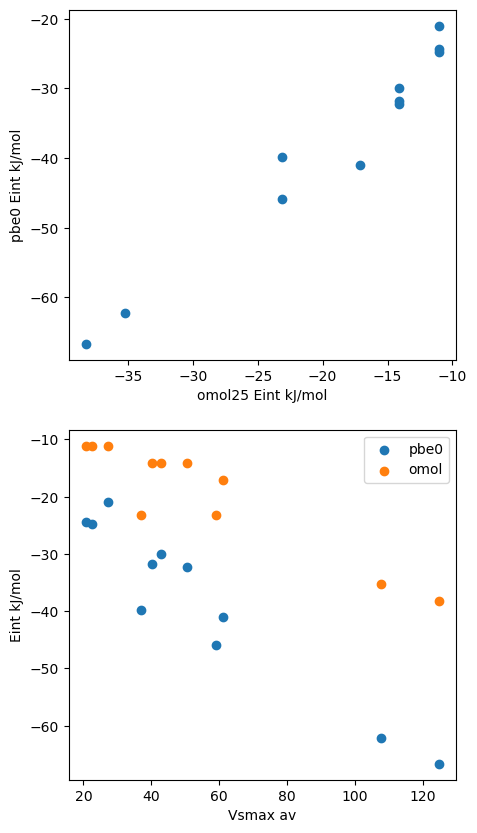

In [10]:
plt.figure("inh")
fig, ax = plt.subplots(2,1, figsize = (5,10))

ax[0].scatter(df_inherent_tot["omol25 inh dE kJ/mol"], df_inherent_tot["svp inh dE kJ/mol"])
ax[0].set_xlabel("omol25 Eint kJ/mol")
ax[0].set_ylabel("pbe0 Eint kJ/mol")

ax[1].scatter(df_inherent_tot["Vsmax av"], df_inherent_tot["svp inh dE kJ/mol"], label="pbe0")
ax[1].scatter(df_inherent_tot["Vsmax av"], df_inherent_tot["omol25 inh dE kJ/mol"], label="omol")
ax[1].set_xlabel("Vsmax av")
ax[1].set_ylabel("Eint kJ/mol")
ax[1].legend()

plt.show()

### mlip tzvp sp

In [10]:
df_tzvp_mlip_subads = glog_to_energies_df("~/TiO2_organized/09_subads_g16_sp", "tio12CDa_co_site*_opt-omol25_low_sp-pbe0_def2tzvp.log", "mlip tzvp")
energy_tzvp_ads = extract_g16_energy("../04_adsorbates_g16_opt/co_opt-pbe0_def2tzvp.log")
energy_tzvp_sub = extract_g16_energy("../04_cluster_g16_sp/tio12CDa_sp-pbe0_def2tzvp_opt-pbe0_def2svp.log")
energy_tzvp_sum = energy_tzvp_ads + energy_tzvp_sub
print(energy_tzvp_sum)
df_tzvp_mlip_subads

11
11
-12111.408980466458


,Structures,mlip tzvp
0,co_site36,-12111.432401
1,co_site38,-12111.430507
2,co_site40,-12111.420457
3,co_site42,-12111.423856
4,co_site44,-12111.418066
5,co_site46,-12111.416912
6,co_site48,-12111.418165
7,co_site50,-12111.419053
8,co_site52,-12111.414632
9,co_site54,-12111.414406


In [11]:
df_tzvp_mlip_subads.loc[:,"omol25 tzvp dE eV"] = (df_tzvp_mlip_subads.loc[:,"mlip tzvp"] - energy_tzvp_sum) * hartree_to_eV
df_tzvp_mlip_subads

,Structures,mlip tzvp,omol25 tzvp dE eV
0,co_site36,-12111.432401,-0.637316
1,co_site38,-12111.430507,-0.585759
2,co_site40,-12111.420457,-0.312303
3,co_site42,-12111.423856,-0.404789
4,co_site44,-12111.418066,-0.247227
5,co_site46,-12111.416912,-0.215820
6,co_site48,-12111.418165,-0.249935
7,co_site50,-12111.419053,-0.274099
8,co_site52,-12111.414632,-0.153800
9,co_site54,-12111.414406,-0.147628


In [12]:
#df_tot = pd.concat([df_inherent_tot, df_tzvp_mlip_subads.loc[:,"omol25 tzvp dE eV"]], axis = 1)
df_tot = df_inherent_tot.copy()
df_tot.insert(3,"omol25 tzvp dE eV",df_tzvp_mlip_subads.loc[:,"omol25 tzvp dE eV"])

df_tot

,structures,Vsmax omol25,omol25 inh dE eV,omol25 tzvp dE eV,Vsmax svp,svp inh dE eV
0,co_site36,124.64,-0.427246,-0.637316,124.49,-0.690781
1,co_site38,109.17,-0.395996,-0.585759,106.04,-0.644857
2,co_site40,60.61,-0.208496,-0.312303,61.55,-0.424948
3,co_site42,58.75,-0.239746,-0.404789,59.38,-0.475852
4,co_site44,51.22,-0.114746,-0.247227,49.99,-0.334021
5,co_site46,44.29,-0.114746,-0.215820,41.54,-0.310921
6,co_site48,40.24,-0.145996,-0.249935,39.96,-0.329765
7,co_site50,38.71,-0.239746,-0.274099,35.47,-0.412926
8,co_site52,27.58,-0.083496,-0.153800,26.76,-0.217502
9,co_site54,22.20,-0.114746,-0.147628,22.64,-0.217494


### svp tzvp sp

In [13]:
df_tzvp_svp_subads = glog_to_energies_df("~/TiO2_organized/09_subads_g16_sp", "tio12CDa_co_site*_opt-pbe0_def2svp_sp-pbe0_def2tzvp.log", "svp tzvp")

df_tzvp_svp_subads

11
11


,Structures,svp tzvp
0,co_site36,-12111.431988
1,co_site38,-12111.430211
2,co_site40,-12111.420409
3,co_site42,-12111.423495
4,co_site44,-12111.418009
5,co_site46,-12111.416573
6,co_site48,-12111.418060
7,co_site50,-12111.419622
8,co_site52,-12111.414621
9,co_site54,-12111.414626


In [14]:
df_tzvp_svp_subads.loc[:,"svp tzvp dE eV"] = (df_tzvp_svp_subads.loc[:,"svp tzvp"] - energy_tzvp_sum) * hartree_to_eV
df_tzvp_svp_subads

,Structures,svp tzvp,svp tzvp dE eV
0,co_site36,-12111.431988,-0.626075
1,co_site38,-12111.430211,-0.577712
2,co_site40,-12111.420409,-0.310981
3,co_site42,-12111.423495,-0.394950
4,co_site44,-12111.418009,-0.245674
5,co_site46,-12111.416573,-0.206598
6,co_site48,-12111.418060,-0.247067
7,co_site50,-12111.419622,-0.289571
8,co_site52,-12111.414621,-0.153498
9,co_site54,-12111.414626,-0.153628


In [15]:
df_tot = pd.concat([df_tot, df_tzvp_svp_subads.loc[:,"svp tzvp dE eV"]], axis = 1)
df_tot

,structures,Vsmax omol25,omol25 inh dE eV,omol25 tzvp dE eV,Vsmax svp,svp inh dE eV,svp tzvp dE eV
0,co_site36,124.64,-0.427246,-0.637316,124.49,-0.690781,-0.626075
1,co_site38,109.17,-0.395996,-0.585759,106.04,-0.644857,-0.577712
2,co_site40,60.61,-0.208496,-0.312303,61.55,-0.424948,-0.310981
3,co_site42,58.75,-0.239746,-0.404789,59.38,-0.475852,-0.394950
4,co_site44,51.22,-0.114746,-0.247227,49.99,-0.334021,-0.245674
5,co_site46,44.29,-0.114746,-0.215820,41.54,-0.310921,-0.206598
6,co_site48,40.24,-0.145996,-0.249935,39.96,-0.329765,-0.247067
7,co_site50,38.71,-0.239746,-0.274099,35.47,-0.412926,-0.289571
8,co_site52,27.58,-0.083496,-0.153800,26.76,-0.217502,-0.153498
9,co_site54,22.20,-0.114746,-0.147628,22.64,-0.217494,-0.153628


### tzvp absolute compare

In [16]:
df_abs_tot = pd.concat([df_tzvp_mlip_subads.drop("omol25 tzvp dE eV", axis=1), df_tzvp_svp_subads.loc[:,"svp tzvp"]], axis = 1)
df_abs_tot

,Structures,mlip tzvp,svp tzvp
0,co_site36,-12111.432401,-12111.431988
1,co_site38,-12111.430507,-12111.430211
2,co_site40,-12111.420457,-12111.420409
3,co_site42,-12111.423856,-12111.423495
4,co_site44,-12111.418066,-12111.418009
5,co_site46,-12111.416912,-12111.416573
6,co_site48,-12111.418165,-12111.418060
7,co_site50,-12111.419053,-12111.419622
8,co_site52,-12111.414632,-12111.414621
9,co_site54,-12111.414406,-12111.414626


In [17]:
ref_abs_tot = df_abs_tot.loc[0,"mlip tzvp"]
df_abs_tot.iloc[:,1:3] = df_abs_tot.iloc[:,1:3] - ref_abs_tot
df_abs_tot

,Structures,mlip tzvp,svp tzvp
0,co_site36,0.000000,0.000413
1,co_site38,0.001895,0.002190
2,co_site40,0.011944,0.011993
3,co_site42,0.008545,0.008907
4,co_site44,0.014335,0.014393
5,co_site46,0.015490,0.015829
6,co_site48,0.014236,0.014341
7,co_site50,0.013348,0.012779
8,co_site52,0.017769,0.017780
9,co_site54,0.017996,0.017775


### Summary

df_tot: adsorption energies = product - reactants
,where 2 inh use their own method optimized structures and energies
tzvp use tzvp opt adsorbate, and methods opt clusters + tzvp sp energies

df_abs_tot: are subads absolute energies relative to mlip site 36 (the lowest)

In [18]:
df_tot

,structures,Vsmax omol25,omol25 inh dE eV,omol25 tzvp dE eV,Vsmax svp,svp inh dE eV,svp tzvp dE eV
0,co_site36,124.64,-0.427246,-0.637316,124.49,-0.690781,-0.626075
1,co_site38,109.17,-0.395996,-0.585759,106.04,-0.644857,-0.577712
2,co_site40,60.61,-0.208496,-0.312303,61.55,-0.424948,-0.310981
3,co_site42,58.75,-0.239746,-0.404789,59.38,-0.475852,-0.394950
4,co_site44,51.22,-0.114746,-0.247227,49.99,-0.334021,-0.245674
5,co_site46,44.29,-0.114746,-0.215820,41.54,-0.310921,-0.206598
6,co_site48,40.24,-0.145996,-0.249935,39.96,-0.329765,-0.247067
7,co_site50,38.71,-0.239746,-0.274099,35.47,-0.412926,-0.289571
8,co_site52,27.58,-0.083496,-0.153800,26.76,-0.217502,-0.153498
9,co_site54,22.20,-0.114746,-0.147628,22.64,-0.217494,-0.153628


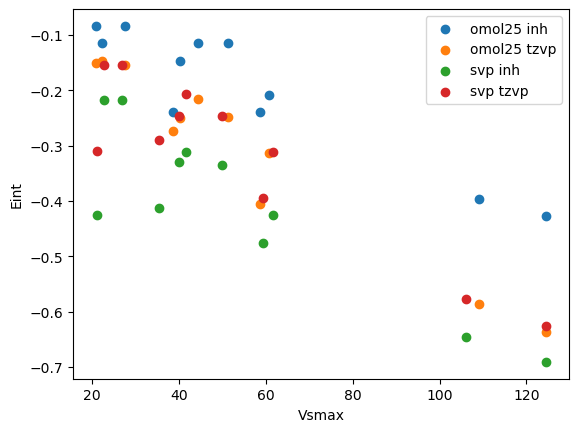

In [19]:
method = ["omol25", "svp"]

fig1 = plt.figure("Eint vs Vsmax")

for i in method:
    plt.scatter(df_tot["Vsmax "+i], df_tot[i+" inh dE eV"], label=i+" inh")
    plt.scatter(df_tot["Vsmax "+i], df_tot[i+" tzvp dE eV"], label=i+" tzvp")

plt.legend()
plt.xlabel("Vsmax")
plt.ylabel("Eint")
plt.show()

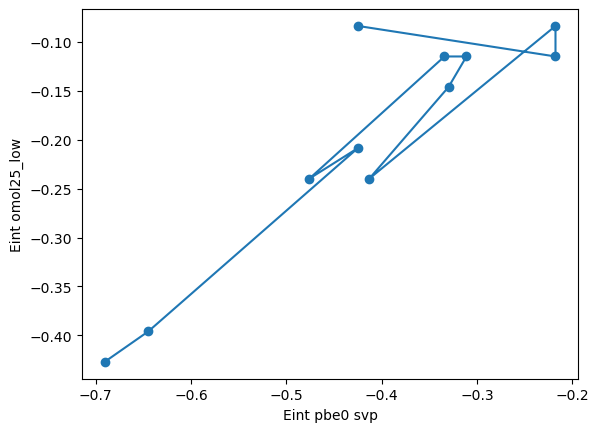

In [25]:
fig2 = plt.figure("omol vs svp")

plt.plot(df_tot["svp inh dE eV"], df_tot["omol25 inh dE eV"], "o-")
plt.xlabel("Eint pbe0 svp")
plt.ylabel("Eint omol25_low")
plt.show()

In [20]:
df_abs_tot

,Structures,mlip tzvp,svp tzvp
0,co_site36,0.000000,0.000413
1,co_site38,0.001895,0.002190
2,co_site40,0.011944,0.011993
3,co_site42,0.008545,0.008907
4,co_site44,0.014335,0.014393
5,co_site46,0.015490,0.015829
6,co_site48,0.014236,0.014341
7,co_site50,0.013348,0.012779
8,co_site52,0.017769,0.017780
9,co_site54,0.017996,0.017775
